In [ ]:
import sklearn
import scikeras

print("sklearn version:", sklearn.__version__)
print("scikeras version:", scikeras.__version__)

sklearn version: 1.5.2
scikeras version: 0.13.0


29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training images shape: (60000, 28, 28)
Training labels shape: (60000,)
Testing images shape: (10000, 28, 28)
Testing labels shape: (10000,)


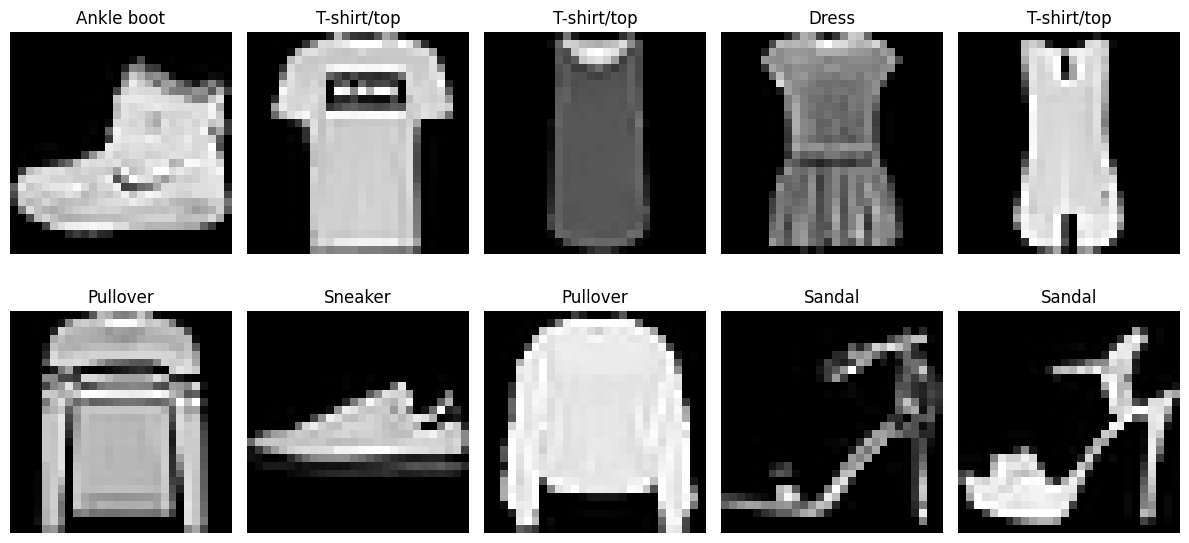

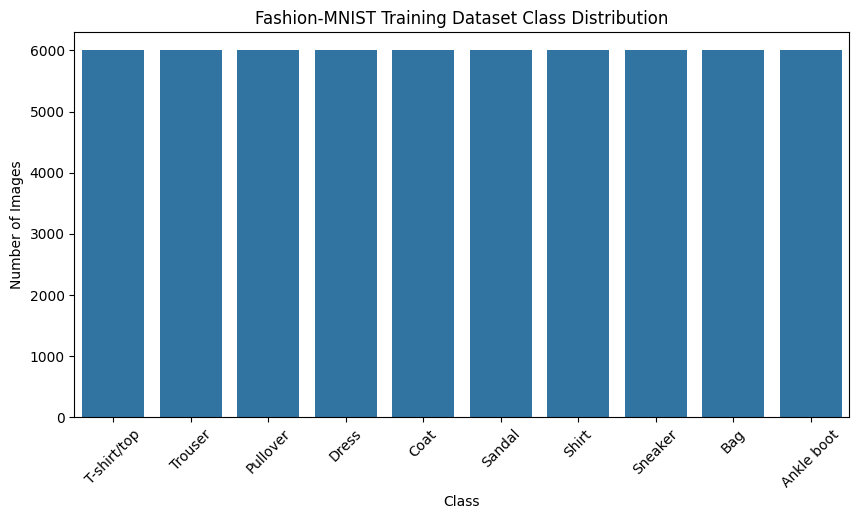

In [ ]:
# Import required libraries
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# -----------------------------------
# 1. Load Fashion-MNIST Dataset
# -----------------------------------

(X_train, y_train), (X_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()


# -----------------------------------
# 2. Print Dataset Dimensions
# -----------------------------------

print("Training images shape:", X_train.shape)
print("Training labels shape:", y_train.shape)

print("Testing images shape:", X_test.shape)
print("Testing labels shape:", y_test.shape)


# Class names for Fashion-MNIST
class_names = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot"
]


# -----------------------------------
# 3. Display 10 Sample Images
# -----------------------------------

plt.figure(figsize=(12, 6))

for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow(X_train[i], cmap="gray")
    plt.title(class_names[y_train[i]])
    plt.axis("off")

plt.tight_layout()
plt.show()



# -----------------------------------
# 4. Plot Class Distribution
# -----------------------------------

plt.figure(figsize=(10,5))

sns.countplot(
    x=y_train,
    order=np.arange(10)
)

plt.xticks(
    ticks=np.arange(10),
    labels=class_names,
    rotation=45
)

plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.title("Fashion-MNIST Training Dataset Class Distribution")

plt.show()

In [ ]:
import tensorflow as tf
import numpy as np

# -----------------------------------
# Load Fashion-MNIST Dataset
# -----------------------------------

(X_train, y_train), (X_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()


# -----------------------------------
# Shapes Before Preprocessing
# -----------------------------------

print("Before Preprocessing:")
print("X_train shape:", X_train.shape)
print("X_test shape :", X_test.shape)

print("y_train shape:", y_train.shape)
print("y_test shape :", y_test.shape)



# -----------------------------------
# 1. Flatten Images
# -----------------------------------
# Convert:
# (60000, 28, 28)
# into:
# (60000, 784)

X_train = X_train.reshape(X_train.shape[0], -1)
X_test = X_test.reshape(X_test.shape[0], -1)



# -----------------------------------
# 2. Normalize Pixel Values
# -----------------------------------
# Original pixel range:
# 0 - 255
#
# New range:
# 0 - 1

X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0



# -----------------------------------
# 3. Shapes After Preprocessing
# -----------------------------------

print("\nAfter Preprocessing:")

print("X_train shape:", X_train.shape)
print("X_test shape :", X_test.shape)

print("y_train shape:", y_train.shape)
print("y_test shape :", y_test.shape)



# Check pixel values after normalization

print("\nPixel value range after normalization:")
print("Minimum value:", X_train.min())
print("Maximum value:", X_train.max())

Before Preprocessing:
X_train shape: (60000, 28, 28)
X_test shape : (10000, 28, 28)
y_train shape: (60000,)
y_test shape : (10000,)

After Preprocessing:
X_train shape: (60000, 784)
X_test shape : (10000, 784)
y_train shape: (60000,)
y_test shape : (10000,)

Pixel value range after normalization:
Minimum value: 0.0
Maximum value: 1.0


In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense


# -----------------------------------
# Build MLP Model
# -----------------------------------

model = Sequential([

    # Input layer + First Hidden Layer
    Dense(
        128,
        activation='relu',
        input_shape=(784,)
    ),

    # Second Hidden Layer
    Dense(
        64,
        activation='relu'
    ),

    # Output Layer
    Dense(
        10,
        activation='softmax'
    )
])


# -----------------------------------
# Display Model Summary
# -----------------------------------

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
import tensorflow as tf


# -----------------------------------
# Convert labels to one-hot encoding
# -----------------------------------

y_train_onehot = tf.keras.utils.to_categorical(y_train, 10)
y_test_onehot = tf.keras.utils.to_categorical(y_test, 10)



# -----------------------------------
# Compile the Model
# -----------------------------------

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)



# -----------------------------------
# Train the Model
# -----------------------------------

history = model.fit(
    X_train,
    y_train_onehot,
    epochs=20,
    batch_size=32,
    validation_data=(X_test, y_test_onehot)
)



Epoch 1/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.8226 - loss: 0.4981 - val_accuracy: 0.8517 - val_loss: 0.4093
Epoch 2/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8655 - loss: 0.3671 - val_accuracy: 0.8561 - val_loss: 0.3855
Epoch 3/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8774 - loss: 0.3317 - val_accuracy: 0.8665 - val_loss: 0.3685
Epoch 4/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.8839 - loss: 0.3111 - val_accuracy: 0.8729 - val_loss: 0.3571
Epoch 5/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.8910 - loss: 0.2925 - val_accuracy: 0.8800 - val_loss: 0.3379
Epoch 6/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8954 - loss: 0.2787 - val_accuracy: 0.8769 - val_loss: 0.3475
Epoch 7/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9012 - loss: 0.2648 - val_accuracy: 0.8811 - val_loss: 0.3296
Epoch 8/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9030 - loss: 0.2553

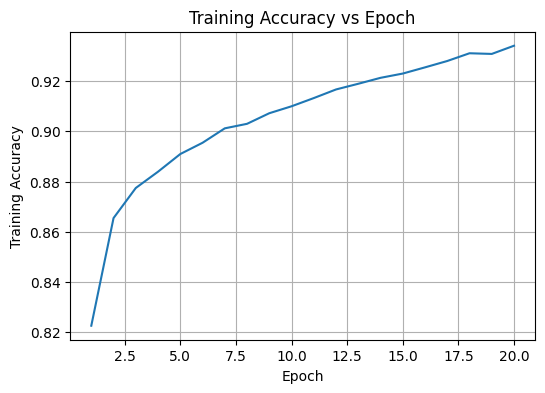

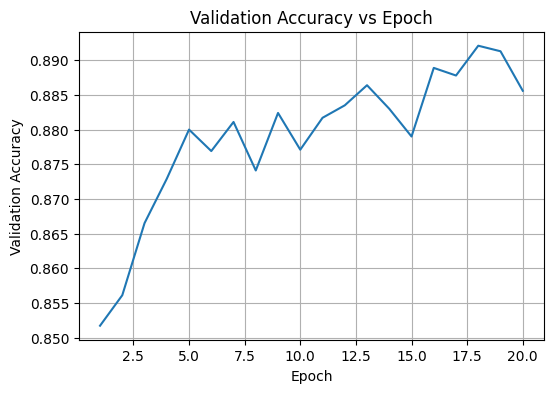

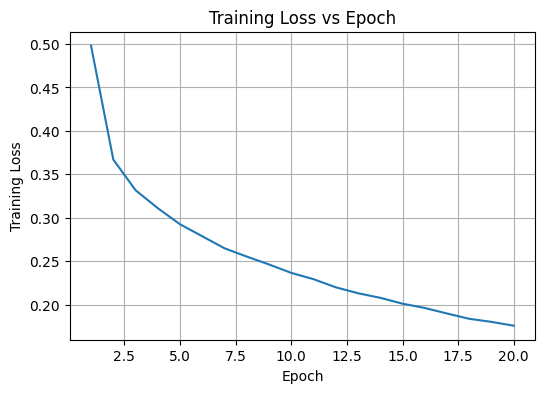

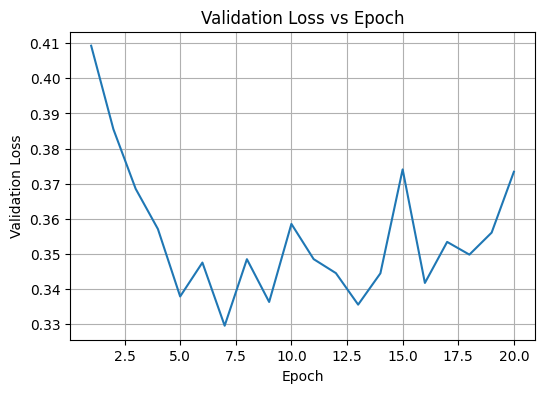

In [ ]:
import matplotlib.pyplot as plt


# Get values from training history
train_accuracy = history.history['accuracy']
val_accuracy = history.history['val_accuracy']

train_loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(1, len(train_accuracy) + 1)


# -----------------------------------
# 1. Training Accuracy vs Epoch
# -----------------------------------

plt.figure(figsize=(6,4))

plt.plot(epochs, train_accuracy)

plt.xlabel("Epoch")
plt.ylabel("Training Accuracy")
plt.title("Training Accuracy vs Epoch")

plt.grid(True)
plt.show()



# -----------------------------------
# 2. Validation Accuracy vs Epoch
# -----------------------------------

plt.figure(figsize=(6,4))

plt.plot(epochs, val_accuracy)

plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("Validation Accuracy vs Epoch")

plt.grid(True)
plt.show()



# -----------------------------------
# 3. Training Loss vs Epoch
# -----------------------------------

plt.figure(figsize=(6,4))

plt.plot(epochs, train_loss)

plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Training Loss vs Epoch")

plt.grid(True)
plt.show()



# -----------------------------------
# 4. Validation Loss vs Epoch
# -----------------------------------

plt.figure(figsize=(6,4))

plt.plot(epochs, val_loss)

plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.title("Validation Loss vs Epoch")

plt.grid(True)
plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step
Accuracy: 0.8856
Precision: 0.8888455912727179
Recall: 0.8856
F1 Score: 0.8867581338916847

Classification Report:

              precision    recall  f1-score   support

 T-shirt/top       0.86      0.81      0.84      1000
     Trouser       0.99      0.97      0.98      1000
    Pullover       0.78      0.81      0.79      1000
       Dress       0.92      0.85      0.88      1000
        Coat       0.78      0.81      0.79      1000
      Sandal       0.97      0.98      0.97      1000
       Shirt       0.68      0.74      0.71      1000
     Sneaker       0.95      0.97      0.96      1000
         Bag       0.98      0.97      0.98      1000
  Ankle boot       0.97      0.95      0.96      1000

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000



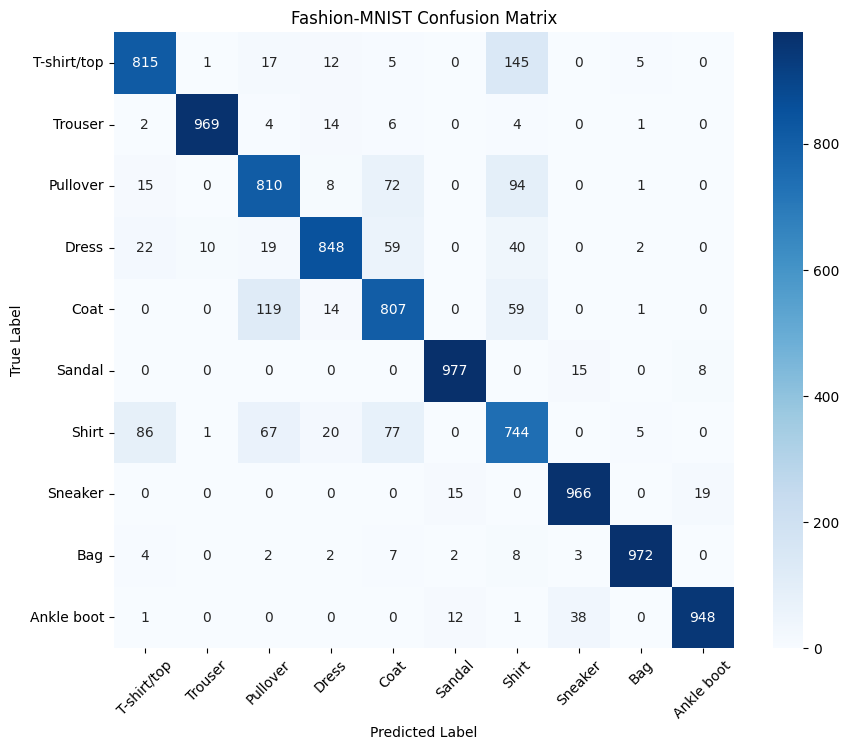

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)


# -----------------------------------
# Make Predictions
# -----------------------------------

# Predict probabilities
y_pred_prob = model.predict(X_test)

# Convert probabilities to class labels
y_pred = np.argmax(y_pred_prob, axis=1)


# Original test labels
y_true = y_test



# -----------------------------------
# 1. Accuracy
# -----------------------------------

accuracy = accuracy_score(
    y_true,
    y_pred
)

print("Accuracy:", accuracy)



# -----------------------------------
# 2. Precision
# -----------------------------------

precision = precision_score(
    y_true,
    y_pred,
    average='weighted'
)

print("Precision:", precision)



# -----------------------------------
# 3. Recall
# -----------------------------------

recall = recall_score(
    y_true,
    y_pred,
    average='weighted'
)

print("Recall:", recall)



# -----------------------------------
# 4. F1 Score
# -----------------------------------

f1 = f1_score(
    y_true,
    y_pred,
    average='weighted'
)

print("F1 Score:", f1)



# -----------------------------------
# 5. Classification Report
# -----------------------------------

print("\nClassification Report:\n")

print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names
    )
)



# -----------------------------------
# 6. Confusion Matrix
# -----------------------------------

cm = confusion_matrix(
    y_true,
    y_pred
)


plt.figure(figsize=(10,8))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)


plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Fashion-MNIST Confusion Matrix")

plt.xticks(rotation=45)
plt.yticks(rotation=0)

plt.show()

In [ ]:
# =====================================================
# Load and Preprocess Fashion-MNIST Dataset
# =====================================================

import tensorflow as tf
import numpy as np


# Load dataset

(X_train, y_train), (X_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()


# Check original shapes

print("Before preprocessing:")
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)



# Flatten images
# 28 x 28 --> 784

X_train = X_train.reshape(X_train.shape[0], 784)
X_test = X_test.reshape(X_test.shape[0], 784)



# Normalize pixel values

X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0



# Check final shapes

print("\nAfter preprocessing:")
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

Before preprocessing:
X_train: (60000, 28, 28)
X_test : (10000, 28, 28)

After preprocessing:
X_train: (60000, 784)
X_test : (10000, 784)
y_train: (60000,)
y_test : (10000,)


In [ ]:
# =====================================================
# Task 7: Hyperparameter Optimization using SciKeras
# RandomizedSearchCV with 5-Fold Cross Validation
# =====================================================

import tensorflow as tf
import numpy as np

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

from scikeras.wrappers import KerasClassifier

from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import accuracy_score, classification_report


# -----------------------------------------------------
# 1. Baseline MLP Model
# -----------------------------------------------------

def build_baseline_model():

    model = Sequential([
        Dense(128, activation="relu", input_shape=(784,)),
        Dense(64, activation="relu"),
        Dense(10, activation="softmax")
    ])

    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model



# Train Baseline Model

baseline_model = build_baseline_model()

baseline_model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)


# Baseline Evaluation

baseline_accuracy = baseline_model.evaluate(
    X_test,
    y_test,
    verbose=0
)[1]


print("\nBaseline Test Accuracy:",
      baseline_accuracy)



# -----------------------------------------------------
# 2. Function for Hyperparameter Model
# -----------------------------------------------------

def create_mlp(
        hidden_layers=1,
        neurons=128,
        learning_rate=0.001,
        optimizer="adam",
        activation="relu",
        dropout_rate=0.0
):

    model = Sequential()


    # First hidden layer
    model.add(
        Dense(
            neurons,
            activation=activation,
            input_shape=(784,)
        )
    )


    # Additional hidden layers

    for i in range(hidden_layers-1):

        model.add(
            Dense(
                neurons,
                activation=activation
            )
        )

        if dropout_rate > 0:
            model.add(
                Dropout(dropout_rate)
            )


    # Output layer

    model.add(
        Dense(
            10,
            activation="softmax"
        )
    )


    # Optimizer selection

    if optimizer == "adam":

        opt = tf.keras.optimizers.Adam(
            learning_rate=learning_rate
        )

    elif optimizer == "sgd":

        opt = tf.keras.optimizers.SGD(
            learning_rate=learning_rate
        )

    else:

        opt = tf.keras.optimizers.RMSprop(
            learning_rate=learning_rate
        )


    model.compile(
        optimizer=opt,
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )


    return model



# -----------------------------------------------------
# 3. SciKeras Wrapper
# -----------------------------------------------------

mlp = KerasClassifier(
    model=create_mlp,
    verbose=0
)



# -----------------------------------------------------
# 4. Hyperparameter Search Space
# -----------------------------------------------------

parameter_grid = {


    # Architecture
    "model__hidden_layers":
        [1,2,3],

    "model__neurons":
        [32,64,128,256],


    # Learning
    "model__learning_rate":
        [0.1,0.01,0.001],


    # Optimizer
    "model__optimizer":
        [
            "adam",
            "sgd",
            "rmsprop"
        ],


    # Activation
    "model__activation":
        [
            "relu",
            "tanh",
            "sigmoid"
        ],


    # Regularization
    "model__dropout_rate":
        [
            0.0,
            0.2,
            0.5
        ],


    # Training
    "batch_size":
        [16,32,64,128],

    "epochs":
        [10,20,30]

}



# -----------------------------------------------------
# 5. Randomized Search with 5 Fold CV
# -----------------------------------------------------

random_search = RandomizedSearchCV(

    estimator=mlp,

    param_distributions=parameter_grid,

    n_iter=20,

    cv=5,

    scoring="accuracy",

    n_jobs=-1,

    verbose=2
)



random_search.fit(
    X_train,
    y_train
)



# -----------------------------------------------------
# 6. Best Hyperparameters
# -----------------------------------------------------

print("\nBest Hyperparameters:")

print(
    random_search.best_params_
)


print("\nBest Cross Validation Accuracy:")

print(
    random_search.best_score_
)



# -----------------------------------------------------
# 7. Evaluate Optimized Model
# -----------------------------------------------------

best_model = random_search.best_estimator_


optimized_accuracy = best_model.score(
    X_test,
    y_test
)


print("\nOptimized Test Accuracy:")

print(
    optimized_accuracy
)



# -----------------------------------------------------
# 8. Comparison
# -----------------------------------------------------

print("\n========== MODEL COMPARISON ==========")

print(
    "Baseline Accuracy:",
    baseline_accuracy
)


print(
    "Optimized Accuracy:",
    optimized_accuracy
)



# -----------------------------------------------------
# 9. Classification Report
# -----------------------------------------------------

y_pred = best_model.predict(
    X_test
)


print("\nClassification Report:\n")

print(
    classification_report(
        y_test,
        y_pred
    )
)

Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.8185 - loss: 0.5134 - val_accuracy: 0.8450 - val_loss: 0.4197
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8626 - loss: 0.3770 - val_accuracy: 0.8671 - val_loss: 0.3620
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8745 - loss: 0.3414 - val_accuracy: 0.8688 - val_loss: 0.3623
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8812 - loss: 0.3173 - val_accuracy: 0.8704 - val_loss: 0.3527
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8878 - loss: 0.2979 - val_accuracy: 0.8808 - val_loss: 0.3287
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.8943 - loss: 0.2825 - val_accuracy: 0.8794 - val_loss: 0.3426
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8993 - loss: 0.2711 - val_accuracy: 0.8848 - val_loss: 0.3197
Epoch 8/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9027 - loss: 0.2574 - 

/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/numpy/ma/core.py:2895: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,
/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



Best Hyperparameters:
{'model__optimizer': 'rmsprop', 'model__neurons': 128, 'model__learning_rate': 0.001, 'model__hidden_layers': 1, 'model__dropout_rate': 0.5, 'model__activation': 'relu', 'epochs': 20, 'batch_size': 32}

Best Cross Validation Accuracy:
0.8849666666666666

Optimized Test Accuracy:
0.881

========== MODEL COMPARISON ==========
Baseline Accuracy: 0.8871999979019165
Optimized Accuracy: 0.881

Classification Report:

              precision    recall  f1-score   support

           0       0.85      0.81      0.83      1000
           1       0.99      0.97      0.98      1000
           2       0.86      0.70      0.77      1000
           3       0.88      0.91      0.89      1000
           4       0.75      0.85      0.80      1000
           5       0.98      0.95      0.96      1000
           6       0.67      0.73      0.70      1000
           7       0.93      0.97      0.95      1000
           8       0.97      0.96      0.97      1000
           9       0.

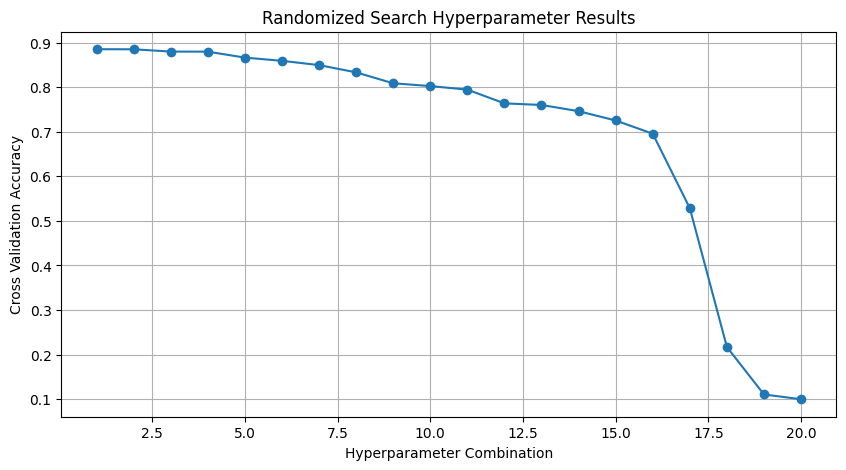

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd


# Convert RandomizedSearchCV results into DataFrame

results = pd.DataFrame(
    random_search.cv_results_
)


# Sort models based on validation accuracy

results = results.sort_values(
    by="mean_test_score",
    ascending=False
)


# Create model numbers

model_numbers = range(
    1,
    len(results)+1
)


plt.figure(figsize=(10,5))

plt.plot(
    model_numbers,
    results["mean_test_score"],
    marker="o"
)


plt.xlabel("Hyperparameter Combination")
plt.ylabel("Cross Validation Accuracy")

plt.title(
    "Randomized Search Hyperparameter Results"
)

plt.grid(True)

plt.show()

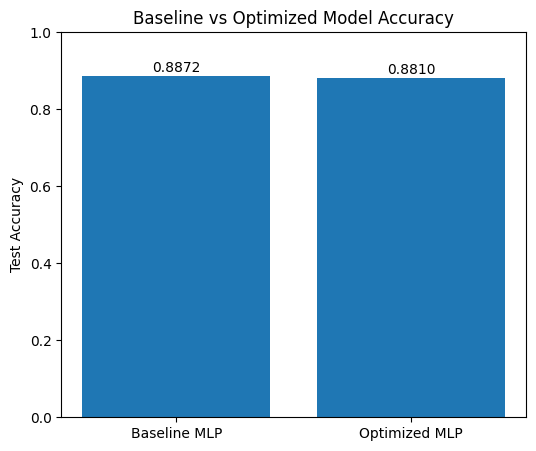

In [ ]:

import matplotlib.pyplot as plt


# Accuracy values

models = [
    "Baseline MLP",
    "Optimized MLP"
]


accuracies = [
    baseline_accuracy,
    optimized_accuracy
]


# Plot

plt.figure(figsize=(6,5))


plt.bar(
    models,
    accuracies
)


plt.ylabel(
    "Test Accuracy"
)


plt.ylim(
    0,
    1
)


plt.title(
    "Baseline vs Optimized Model Accuracy"
)


# Add accuracy values on bars

for i, value in enumerate(accuracies):

    plt.text(
        i,
        value + 0.01,
        f"{value:.4f}",
        ha="center"
    )


plt.show()

In [ ]:
# =====================================================
# Task 9: Results Extraction
# =====================================================

import time
import pandas as pd

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)



# -----------------------------------------------------
# 1. Best Hyperparameters
# -----------------------------------------------------

print("========== BEST HYPERPARAMETERS ==========\n")


best_params = random_search.best_params_


print("Hidden Layers:",
      best_params["model__hidden_layers"])

print("Hidden Neurons:",
      best_params["model__neurons"])

print("Learning Rate:",
      best_params["model__learning_rate"])

print("Batch Size:",
      best_params["batch_size"])

print("Optimizer:",
      best_params["model__optimizer"])

print("Activation Function:",
      best_params["model__activation"])

print("Epochs:",
      best_params["epochs"])

print("Dropout:",
      best_params["model__dropout_rate"])



print("\nCross-validation Accuracy:")

print(
    random_search.best_score_
)



# -----------------------------------------------------
# 2. Baseline Model Metrics
# -----------------------------------------------------

print("\n========== BASELINE MODEL ==========")


# Prediction

baseline_pred_prob = baseline_model.predict(X_test)

baseline_pred = baseline_pred_prob.argmax(axis=1)



baseline_accuracy = accuracy_score(
    y_test,
    baseline_pred
)


baseline_precision = precision_score(
    y_test,
    baseline_pred,
    average="weighted"
)


baseline_recall = recall_score(
    y_test,
    baseline_pred,
    average="weighted"
)


baseline_f1 = f1_score(
    y_test,
    baseline_pred,
    average="weighted"
)


print("Accuracy:",
      baseline_accuracy)

print("Precision:",
      baseline_precision)

print("Recall:",
      baseline_recall)

print("F1 Score:",
      baseline_f1)



# -----------------------------------------------------
# 3. Optimized Model Metrics
# -----------------------------------------------------

print("\n========== OPTIMIZED MODEL ==========")


optimized_model = random_search.best_estimator_


optimized_pred = optimized_model.predict(
    X_test
)



optimized_accuracy = accuracy_score(
    y_test,
    optimized_pred
)


optimized_precision = precision_score(
    y_test,
    optimized_pred,
    average="weighted"
)


optimized_recall = recall_score(
    y_test,
    optimized_pred,
    average="weighted"
)


optimized_f1 = f1_score(
    y_test,
    optimized_pred,
    average="weighted"
)



print("Accuracy:",
      optimized_accuracy)

print("Precision:",
      optimized_precision)

print("Recall:",
      optimized_recall)

print("F1 Score:",
      optimized_f1)



# -----------------------------------------------------
# 4. Testing Accuracy
# -----------------------------------------------------

print("\nOptimized Testing Accuracy:")

print(
    optimized_accuracy
)



# -----------------------------------------------------
# 5. Performance Comparison Table
# -----------------------------------------------------

comparison = pd.DataFrame({

    "Metric":[
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score"
    ],


    "Baseline":[
        baseline_accuracy,
        baseline_precision,
        baseline_recall,
        baseline_f1
    ],


    "Optimized":[
        optimized_accuracy,
        optimized_precision,
        optimized_recall,
        optimized_f1
    ]

})


print("\n========== PERFORMANCE COMPARISON ==========\n")

print(comparison)

========== BEST HYPERPARAMETERS ==========

Hidden Layers: 1
Hidden Neurons: 128
Learning Rate: 0.001
Batch Size: 32
Optimizer: rmsprop
Activation Function: relu
Epochs: 20
Dropout: 0.5

Cross-validation Accuracy:
0.8849666666666666

========== BASELINE MODEL ==========
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Accuracy: 0.8872
Precision: 0.8862816275075713
Recall: 0.8872
F1 Score: 0.886396040141186

========== OPTIMIZED MODEL ==========
Accuracy: 0.881
Precision: 0.8840687675541438
Recall: 0.881
F1 Score: 0.8811836084405108

Optimized Testing Accuracy:
0.881

========== PERFORMANCE COMPARISON ==========

      Metric  Baseline  Optimized
0   Accuracy  0.887200   0.881000
1  Precision  0.886282   0.884069
2     Recall  0.887200   0.881000
3   F1-score  0.886396   0.881184


Initial Weights: [0. 0.]
Initial Bias: 0

Epoch: 1

Update: 1
Input: [0 0]
Target: 0
Prediction: 1
Updated Weights: [0. 0.]
Updated Bias: -1


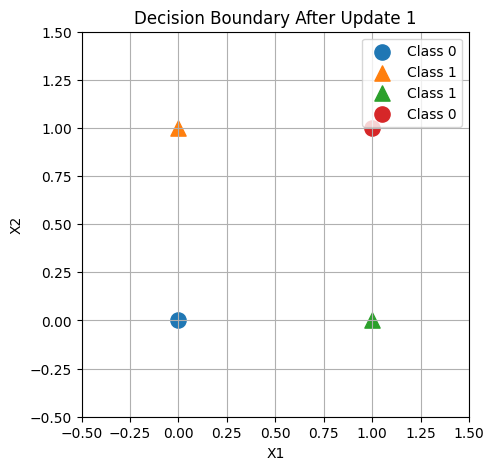


Update: 2
Input: [0 1]
Target: 1
Prediction: 0
Updated Weights: [0. 1.]
Updated Bias: 0


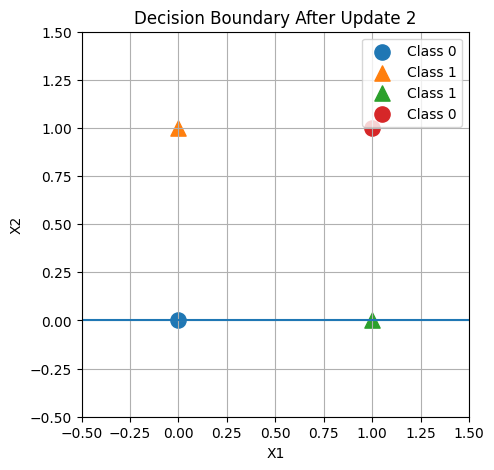


Update: 3
Input: [1 1]
Target: 0
Prediction: 1
Updated Weights: [-1.  0.]
Updated Bias: -1


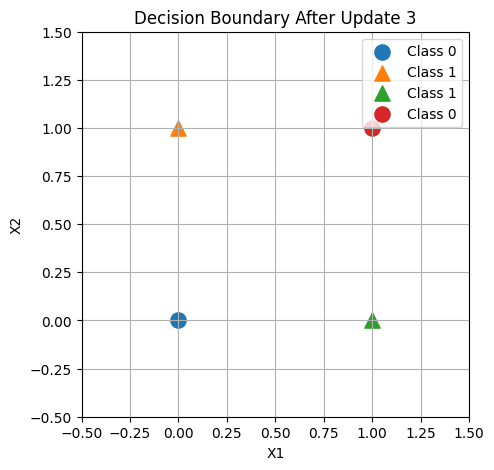


Epoch: 2

Update: 4
Input: [0 1]
Target: 1
Prediction: 0
Updated Weights: [-1.  1.]
Updated Bias: 0


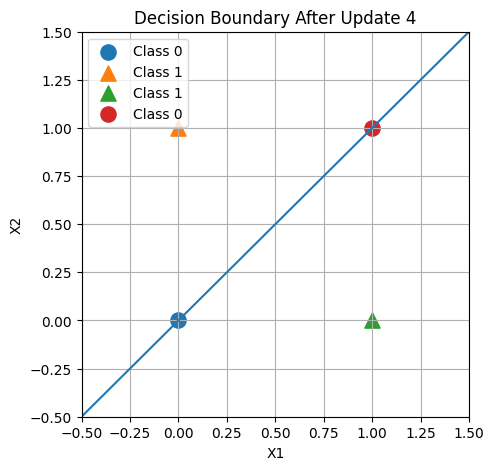


Update: 5
Input: [1 0]
Target: 1
Prediction: 0
Updated Weights: [0. 1.]
Updated Bias: 1


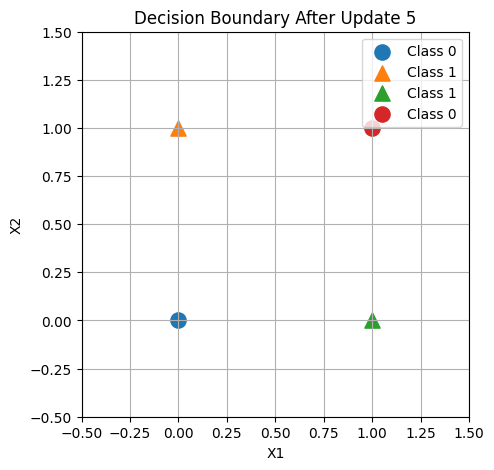


Update: 6
Input: [1 1]
Target: 0
Prediction: 1
Updated Weights: [-1.  0.]
Updated Bias: 0


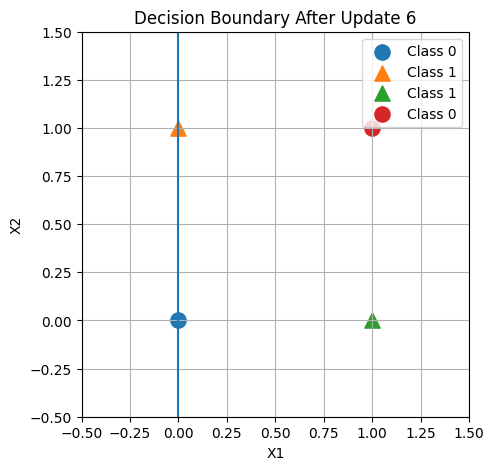


Epoch: 3

Update: 7
Input: [0 0]
Target: 0
Prediction: 1
Updated Weights: [-1.  0.]
Updated Bias: -1


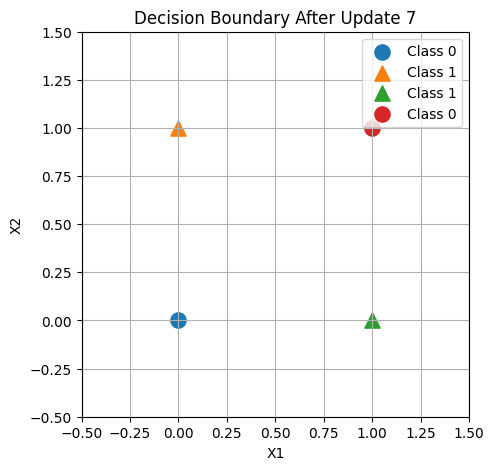


Update: 8
Input: [0 1]
Target: 1
Prediction: 0
Updated Weights: [-1.  1.]
Updated Bias: 0


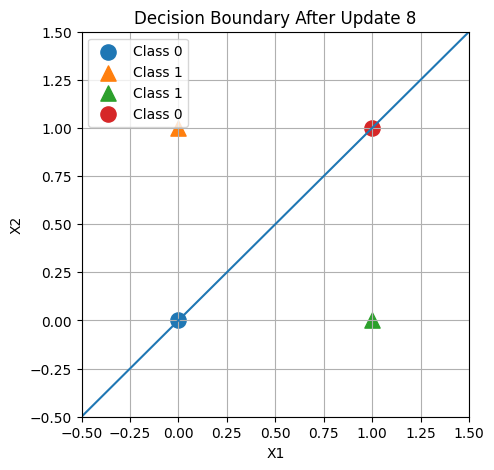


Update: 9
Input: [1 0]
Target: 1
Prediction: 0
Updated Weights: [0. 1.]
Updated Bias: 1


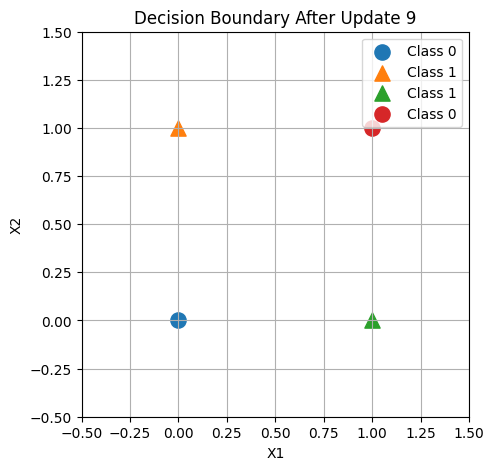


Update: 10
Input: [1 1]
Target: 0
Prediction: 1
Updated Weights: [-1.  0.]
Updated Bias: 0


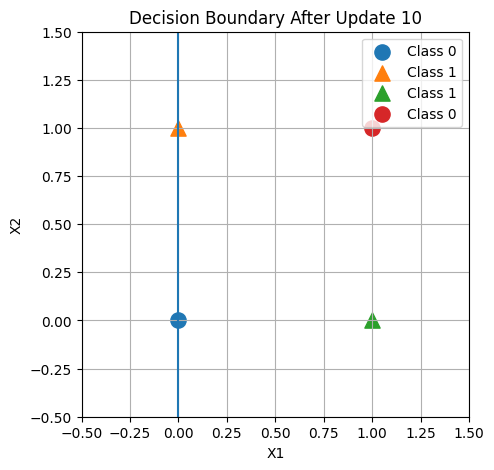


Final Weights: [-1.  0.]
Final Bias: 0

Observation:
The weights keep changing because XOR is not linearly separable.
The perceptron enters an oscillating pattern and never converges.


In [2]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------------
# XOR Dataset
# -----------------------------------
X = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
])

y = np.array([0, 1, 1, 0])


# -----------------------------------
# Perceptron Parameters
# -----------------------------------
learning_rate = 1

weights = np.zeros(2)
bias = 0

epochs = 3        # Reduced epochs


# -----------------------------------
# Activation Function
# -----------------------------------
def activation(x):
    return 1 if x >= 0 else 0


# -----------------------------------
# Decision Boundary Plot
# -----------------------------------
def plot_boundary(weights, bias, update):

    plt.figure(figsize=(5,5))

    # Plot XOR points
    for i in range(len(X)):
        if y[i] == 0:
            plt.scatter(
                X[i][0],
                X[i][1],
                marker='o',
                s=120,
                label="Class 0"
            )
        else:
            plt.scatter(
                X[i][0],
                X[i][1],
                marker='^',
                s=120,
                label="Class 1"
            )


    # Plot decision boundary
    if weights[1] != 0:

        x_values = np.linspace(-0.5,1.5,100)

        y_values = (
            -(weights[0]*x_values + bias)
            /
            weights[1]
        )

        plt.plot(
            x_values,
            y_values
        )

    else:
        if weights[0] != 0:
            plt.axvline(
                -bias/weights[0]
            )


    plt.xlim(-0.5,1.5)
    plt.ylim(-0.5,1.5)

    plt.xlabel("X1")
    plt.ylabel("X2")

    plt.title(
        f"Decision Boundary After Update {update}"
    )

    plt.grid(True)
    plt.legend()
    plt.show()



# -----------------------------------
# Training
# -----------------------------------

update = 0

print("Initial Weights:", weights)
print("Initial Bias:", bias)


for epoch in range(epochs):

    print("\n===================")
    print("Epoch:", epoch+1)
    print("===================")


    for i in range(len(X)):

        # Calculate prediction
        net = np.dot(X[i], weights) + bias

        prediction = activation(net)


        # Calculate error
        error = y[i] - prediction


        # Update only if wrong
        if error != 0:

            weights = (
                weights +
                learning_rate * error * X[i]
            )

            bias = (
                bias +
                learning_rate * error
            )


            update += 1


            print("\nUpdate:", update)
            print("Input:", X[i])
            print("Target:", y[i])
            print("Prediction:", prediction)

            print(
                "Updated Weights:",
                weights
            )

            print(
                "Updated Bias:",
                bias
            )


            # Plot boundary after every update
            plot_boundary(
                weights,
                bias,
                update
            )


print("\nFinal Weights:", weights)
print("Final Bias:", bias)

print("\nObservation:")
print("The weights keep changing because XOR is not linearly separable.")
print("The perceptron enters an oscillating pattern and never converges.")